# Name: Danish Zaheer
# Roll no: 25280092

## 1. Building a Basic VAE in PyTorch

In [1]:
# Imports all libraries used in the VAE notebook.
# Selects the available device and prints GPU information.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.decomposition import PCA

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
# Sets the main VAE training hyperparameters.
# Defines batch size, latent size, hidden size, learning rate, and epochs.
batch_size = 64
latent_dim = 20
hidden_dim = 400
learning_rate = 1e-3
num_epochs = 20

In [4]:
# Downloads and prepares the MNIST dataset.
# Creates train and test DataLoaders for VAE training and evaluation.
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="../Data",train=True,transform=transform,download=True)
test_dataset = datasets.MNIST(root="../Data",train=False,transform=transform,download=True)
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=2,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False,num_workers=2,pin_memory=True)
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 60000
Test samples: 10000


In [5]:
# Defines the VAE encoder network.
# Maps each MNIST image to latent mean and log-variance vectors.
class Encoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        h1 = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h1))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

In [6]:
# Defines the VAE reparameterization function.
# Samples latent vectors using mean, log-variance, and random noise.
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    epsilon = torch.randn_like(std)
    z = mu + std * epsilon
    return z

In [7]:
# Defines the VAE decoder network.
# Maps latent vectors back to reconstructed image logits.
class Decoder(nn.Module):
    def __init__(self, latent_dim=20, hidden_dim=400, output_dim=784):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h1 = F.relu(self.fc1(z))
        h = F.relu(self.fc2(h1))
        logits = self.fc_out(h)
        return logits

In [8]:
# Combines the encoder, reparameterization, and decoder.
# Returns reconstruction logits plus latent distribution parameters.
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.encoder = Encoder(input_dim=input_dim,hidden_dim=hidden_dim,latent_dim=latent_dim)
        self.decoder = Decoder(latent_dim=latent_dim,hidden_dim=hidden_dim,output_dim=input_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        reconstruction_logits = self.decoder(z)
        return reconstruction_logits, mu, logvar

In [9]:
# Creates the VAE model instance.
# Moves the model to the selected device and prints its structure.
model = VAE(input_dim=784,hidden_dim=hidden_dim,latent_dim=latent_dim).to(device)
print(model)

VAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=784, out_features=400, bias=True)
    (fc2): Linear(in_features=400, out_features=400, bias=True)
    (fc_mu): Linear(in_features=400, out_features=20, bias=True)
    (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=20, out_features=400, bias=True)
    (fc2): Linear(in_features=400, out_features=400, bias=True)
    (fc_out): Linear(in_features=400, out_features=784, bias=True)
  )
)


In [10]:
# Defines the VAE negative-ELBO loss.
# Combines binary reconstruction loss with KL divergence.
def vae_loss(reconstruction_logits, x, mu, logvar):
    x = x.view(x.size(0), -1)
    reconstruction_loss = F.binary_cross_entropy_with_logits(reconstruction_logits,x,reduction="sum")
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = reconstruction_loss + kl_divergence
    return total_loss, reconstruction_loss, kl_divergence

In [11]:
# Creates the Adam optimizer for VAE training.
# Uses the configured learning rate over all model parameters.
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)
print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [12]:
# Trains the VAE on MNIST for the selected epochs.
# Tracks total, reconstruction, and KL losses during training.
train_losses = []
train_reconstruction_losses = []
train_kl_losses = []

for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0
    total_reconstruction_loss = 0
    total_kl_loss = 0

    for x, _ in train_loader:
        x = x.to(device, non_blocking=True)
        optimizer.zero_grad()
        reconstruction_logits, mu, logvar = model(x)
        loss, reconstruction_loss, kl_loss = vae_loss(reconstruction_logits,x,mu,logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_reconstruction_loss += reconstruction_loss.item()
        total_kl_loss += kl_loss.item()

    avg_loss = total_loss / len(train_dataset)
    avg_reconstruction = total_reconstruction_loss / len(train_dataset)
    avg_kl = total_kl_loss / len(train_dataset)

    train_losses.append(avg_loss)
    train_reconstruction_losses.append(avg_reconstruction)
    train_kl_losses.append(avg_kl)

    print(
        f"Epoch [{epoch:02d}/{num_epochs}] "
        f"Loss: {avg_loss:.4f} | "
        f"Reconstruction: {avg_reconstruction:.4f} | "
        f"KL: {avg_kl:.4f}")

Epoch [01/20] Loss: 158.9186 | Reconstruction: 149.0172 | KL: 9.9013
Epoch [02/20] Loss: 121.1441 | Reconstruction: 106.1173 | KL: 15.0268
Epoch [03/20] Loss: 113.6549 | Reconstruction: 97.0045 | KL: 16.6504
Epoch [04/20] Loss: 110.2367 | Reconstruction: 92.9964 | KL: 17.2404
Epoch [05/20] Loss: 108.1952 | Reconstruction: 90.6312 | KL: 17.5640
Epoch [06/20] Loss: 106.8085 | Reconstruction: 89.0499 | KL: 17.7586
Epoch [07/20] Loss: 105.7804 | Reconstruction: 87.8517 | KL: 17.9287
Epoch [08/20] Loss: 104.9739 | Reconstruction: 86.9262 | KL: 18.0477
Epoch [09/20] Loss: 104.3609 | Reconstruction: 86.2134 | KL: 18.1475
Epoch [10/20] Loss: 103.7390 | Reconstruction: 85.5259 | KL: 18.2131
Epoch [11/20] Loss: 103.3027 | Reconstruction: 85.0253 | KL: 18.2773
Epoch [12/20] Loss: 102.8807 | Reconstruction: 84.5431 | KL: 18.3377
Epoch [13/20] Loss: 102.5323 | Reconstruction: 84.1411 | KL: 18.3912
Epoch [14/20] Loss: 102.1533 | Reconstruction: 83.7167 | KL: 18.4366
Epoch [15/20] Loss: 101.9047 | Re

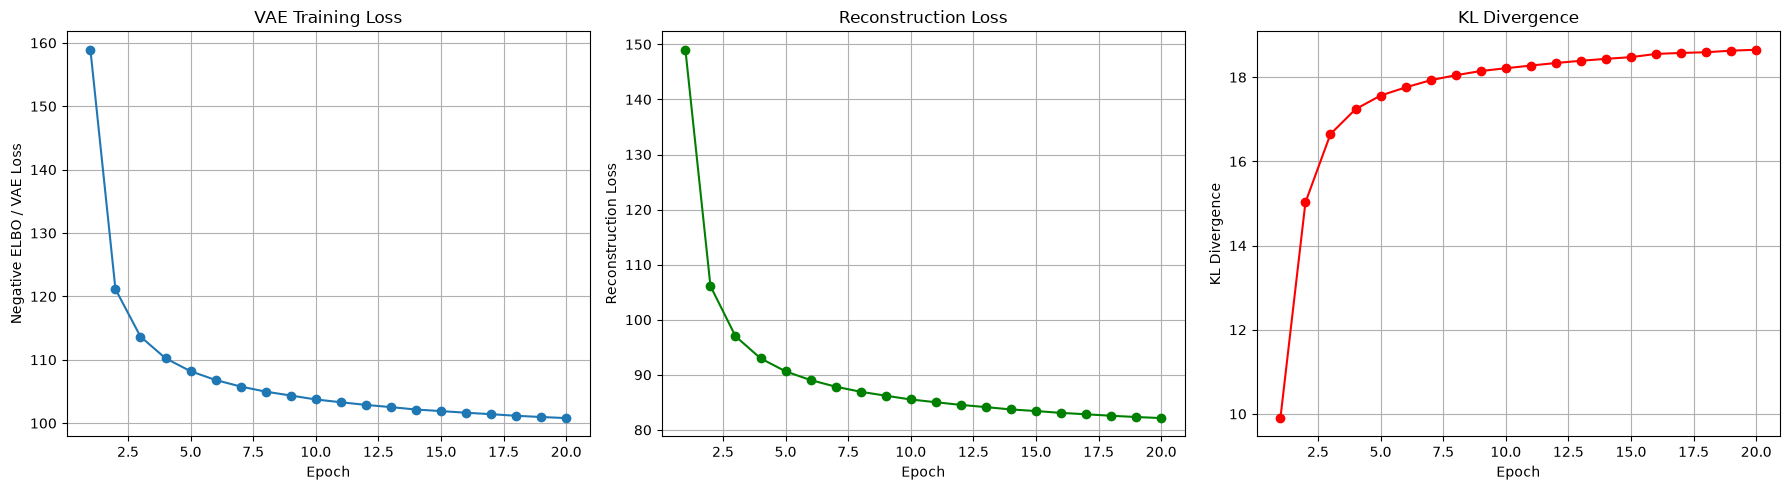

In [13]:
# Plots total VAE loss, reconstruction loss, and KL divergence.
# Shows how each loss component changes across training epochs.
epoch_numbers = range(1,num_epochs + 1)
fig, axes = plt.subplots(1,3,figsize=(18, 5))
axes[0].plot(epoch_numbers,train_losses,marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Negative ELBO / VAE Loss")
axes[0].set_title("VAE Training Loss")
axes[0].grid(True)
axes[1].plot(epoch_numbers,train_reconstruction_losses,marker="o",color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Reconstruction Loss")
axes[1].set_title("Reconstruction Loss")
axes[1].grid(True)
axes[2].plot(epoch_numbers,train_kl_losses,marker="o",color="red")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("KL Divergence")
axes[2].set_title("KL Divergence")
axes[2].grid(True)
plt.tight_layout()
plt.show()

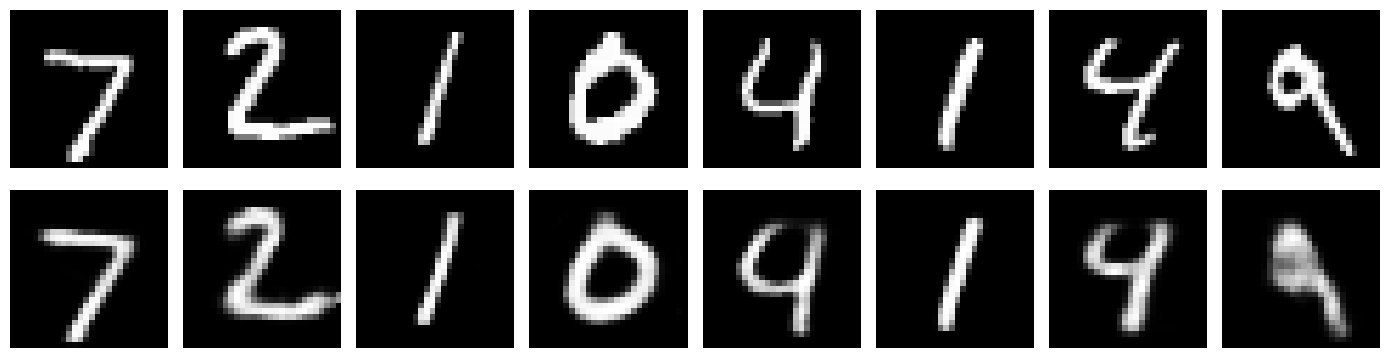

In [14]:
# Reconstructs a batch of MNIST test images.
# Plots original images against VAE reconstructions.
model.eval()

with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    reconstruction_logits, mu, logvar = model(images)
    reconstructed_images = torch.sigmoid(reconstruction_logits)
    reconstructed_images = reconstructed_images.view(-1, 1, 28, 28)

images = images.cpu()
reconstructed_images = reconstructed_images.cpu()
num_images = 8
fig, axes = plt.subplots(2,num_images,figsize=(14, 4))

for i in range(num_images):
    axes[0, i].imshow(images[i].squeeze(),cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructed_images[i].squeeze(),cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original",fontsize=12)
axes[1, 0].set_ylabel("Reconstructed",fontsize=12)
plt.tight_layout()
plt.show()

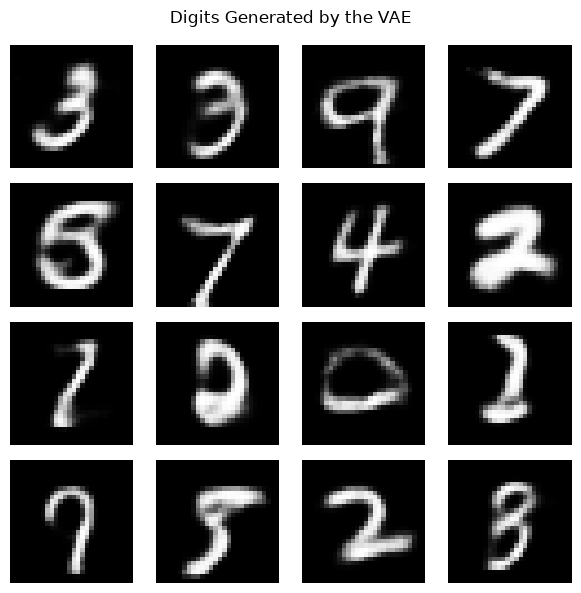

In [15]:
# Generates new MNIST-like samples from random latent vectors.
# Decodes prior samples and displays the generated digits.
model.eval()
num_samples = 16

with torch.no_grad():
    z = torch.randn(num_samples,latent_dim,device=device)
    generated_logits = model.decoder(z)
    generated_images = torch.sigmoid(generated_logits)
    generated_images = generated_images.view(-1, 1, 28, 28)
    generated_images = generated_images.cpu()

fig, axes = plt.subplots(4,4,figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].squeeze(),cmap="gray")
    ax.axis("off")

plt.suptitle("Digits Generated by the VAE")
plt.tight_layout()
plt.show()

## 2. Analyzing VAE Performance:

In [16]:
# Prepares the trained VAE for evaluation.
# Prints the latent dimension used for analysis.
model.eval()
print("Model is ready for evaluation.")
print("Latent dimension:", latent_dim)

Model is ready for evaluation.
Latent dimension: 20


In [17]:
# Encodes the MNIST test set into latent means.
# Stores latent vectors and labels for visualization.
all_mu = []
all_labels = []
model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu, logvar = model.encoder(images)
        mu = mu.cpu()
        all_mu.append(mu)
        all_labels.append(labels)

print("Finished encoding test images.")

Finished encoding test images.


In [18]:
# Combines latent vectors and labels across batches.
# Prints the final tensor shapes for analysis.
all_mu = torch.cat(all_mu, dim=0)
all_labels = torch.cat(all_labels, dim=0)
print("Latent means shape:", all_mu.shape)
print("Labels shape:", all_labels.shape)

Latent means shape: torch.Size([10000, 20])
Labels shape: torch.Size([10000])


In [19]:
# Converts latent means and labels to NumPy arrays.
# Prepares arrays for PCA and plotting.
latent_vectors = all_mu.numpy()
labels = all_labels.numpy()
print("Latent vectors:", latent_vectors.shape)
print("Labels:", labels.shape)

Latent vectors: (10000, 20)
Labels: (10000,)


In [20]:
# Creates a two-dimensional latent representation.
# Uses PCA when the latent dimension is larger than two.
if latent_dim == 2:
    latent_2d = latent_vectors
    print("Latent dimension is already 2.")
    print("No PCA is required.")
else:
    pca = PCA(n_components=2)
    latent_2d = pca.fit_transform(latent_vectors)
    print("Original latent dimension:", latent_dim)
    print("Reduced latent dimension:", latent_2d.shape[1])
    print("Explained variance:", pca.explained_variance_ratio_)

Original latent dimension: 20
Reduced latent dimension: 2
Explained variance: [0.12033731 0.11618599]


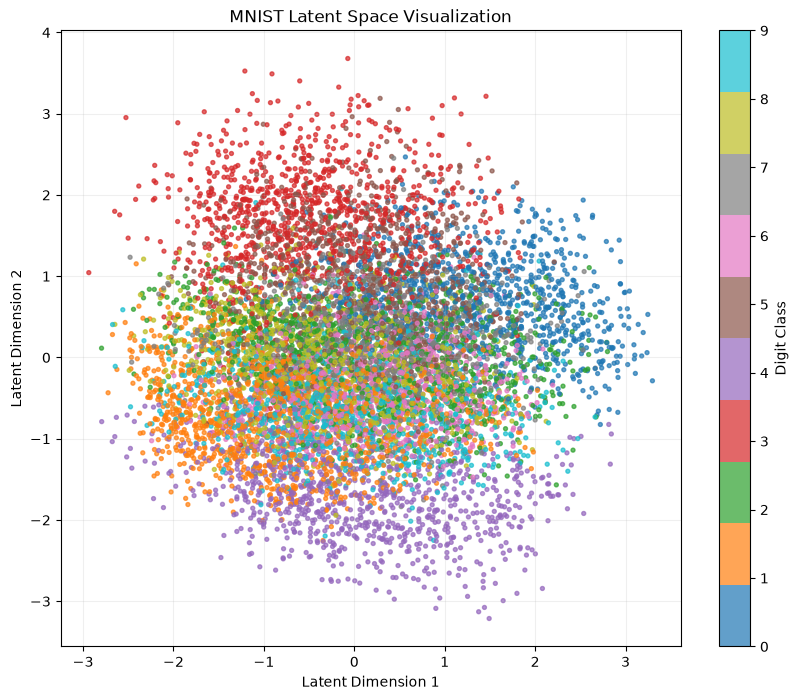

In [21]:
# Visualizes the MNIST latent space.
# Colors latent points by digit class.
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0],latent_2d[:, 1],c=labels,cmap="tab10",s=8,alpha=0.7)
plt.colorbar(scatter,ticks=range(10),label="Digit Class")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("MNIST Latent Space Visualization")
plt.grid(alpha=0.2)
plt.show()

In [22]:
# Loads one test batch for reconstruction inspection.
# Prints the image batch shape.
images, labels = next(iter(test_loader))
print("Batch shape:", images.shape)

Batch shape: torch.Size([64, 1, 28, 28])


In [23]:
# Selects random test images for reconstruction quality.
# Stores the chosen images and their digit labels.
num_images = 8
random_indices = torch.randperm(images.size(0))[:num_images]
sample_images = images[random_indices]
sample_labels = labels[random_indices]
print("Selected digit labels:")
print(sample_labels.tolist())

Selected digit labels:
[0, 9, 9, 5, 3, 0, 6, 1]


In [24]:
# Moves selected test images to the active device.
# Confirms where the reconstruction inputs are stored.
sample_images = sample_images.to(device)
print("Images are on:",sample_images.device)

Images are on: cuda:0


In [25]:
# Runs the VAE on the selected test images.
# Computes reconstruction logits and latent parameters.
model.eval()
with torch.no_grad():
    reconstruction_logits, mu, logvar = model(sample_images)
print("Reconstruction finished.")

Reconstruction finished.


In [26]:
# Converts reconstruction logits into images.
# Reshapes reconstructed outputs back to MNIST image format.
reconstructed_images = torch.sigmoid(reconstruction_logits)
reconstructed_images = reconstructed_images.view(-1,1,28,28)
print(
    "Reconstructed image shape:",
    reconstructed_images.shape)

Reconstructed image shape: torch.Size([8, 1, 28, 28])


In [27]:
# Moves originals, reconstructions, and labels to CPU.
# Prepares tensors for plotting.
original_images = sample_images.cpu()
reconstructed_images = reconstructed_images.cpu()
sample_labels = sample_labels.cpu()

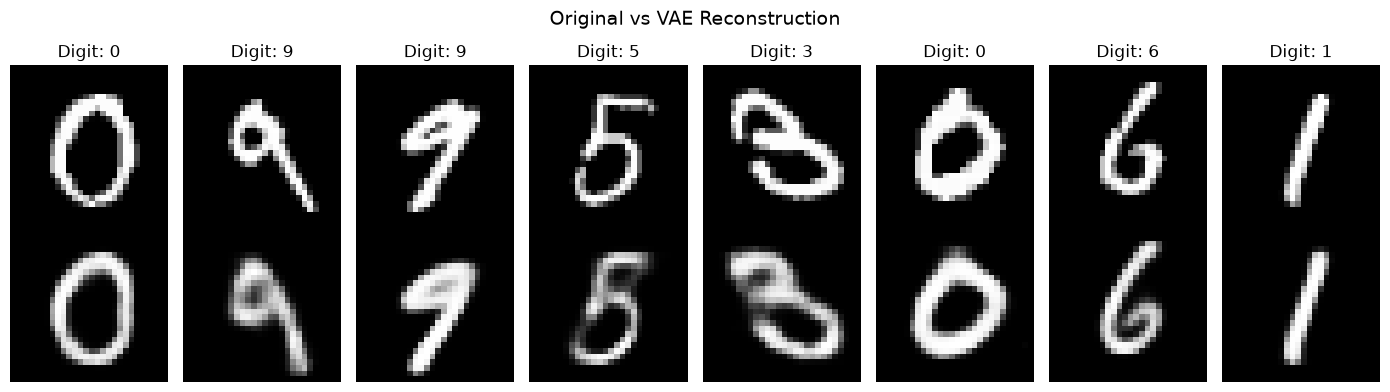

In [28]:
# Plots original versus reconstructed test images.
# Shows reconstruction quality for the selected MNIST samples.
fig, axes = plt.subplots(2,num_images,figsize=(14, 4))
for i in range(num_images):
    axes[0, i].imshow(original_images[i].squeeze(),cmap="gray")
    axes[0, i].set_title(f"Digit: {sample_labels[i].item()}")
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstructed_images[i].squeeze(),cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original",fontsize=12)
axes[1, 0].set_ylabel("Reconstructed",fontsize=12)
plt.suptitle("Original vs VAE Reconstruction",fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
# Sets the number of generated samples.
# Prints how many random digits will be produced.
num_generated = 16
print("Number of digits to generate:",num_generated)

Number of digits to generate: 16


In [30]:
# Samples random latent vectors from the standard normal prior.
# Uses these vectors as decoder inputs for generation.
z_random = torch.randn(num_generated,latent_dim,device=device)
print("Random latent vectors shape:", z_random.shape)

Random latent vectors shape: torch.Size([16, 20])


In [31]:
# Decodes the random latent vectors.
# Prints the raw decoder output shape.
model.eval()
with torch.no_grad():
    generated_logits = model.decoder(z_random)
print("Decoder output shape:", generated_logits.shape)

Decoder output shape: torch.Size([16, 784])


In [32]:
# Converts generated logits into pixel probabilities.
# Reports the generated image value range.
generated_images = torch.sigmoid(generated_logits)
print("Minimum pixel value:",generated_images.min().item())
print("Maximum pixel value:",generated_images.max().item())

Minimum pixel value: 1.5663415589494088e-36
Maximum pixel value: 0.9992154836654663


In [33]:
# Reshapes generated vectors into MNIST image tensors.
# Moves generated images to CPU for display.
generated_images = generated_images.view(-1,1,28,28)
generated_images = generated_images.cpu()
print("Generated image shape:", generated_images.shape)

Generated image shape: torch.Size([16, 1, 28, 28])


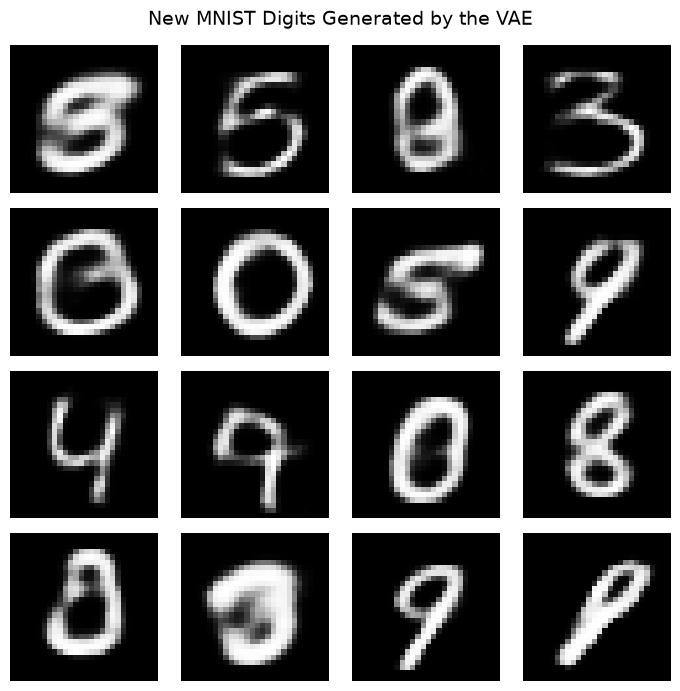

In [34]:
# Plots generated MNIST-like digits.
# Displays samples decoded from random latent vectors.
fig, axes = plt.subplots(4,4,figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].squeeze(),cmap="gray")
    ax.axis("off")

plt.suptitle("New MNIST Digits Generated by the VAE",fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
# Generates a small set of random VAE samples.
# Decodes five latent vectors into image tensors.
num_samples = 5
with torch.no_grad():
    z = torch.randn(num_samples,latent_dim,device=device)
    logits = model.decoder(z)
    new_images = torch.sigmoid(logits)
    new_images = new_images.view(-1,1,28,28)
    new_images = new_images.cpu()

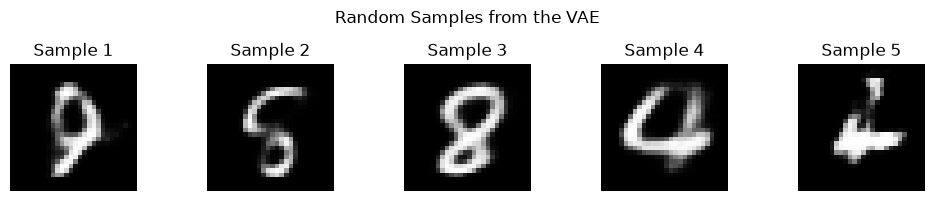

In [36]:
# Displays five random VAE samples.
# Shows generated digits in a compact row.
fig, axes = plt.subplots(1,5,figsize=(10, 2))
for i in range(5):
    axes[i].imshow(new_images[i].squeeze(),cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Sample {i + 1}")

plt.suptitle("Random Samples from the VAE")
plt.tight_layout()
plt.show()

In [37]:
# Generates a larger grid of VAE samples.
# Decodes twenty-five random latent vectors.
num_samples = 25
model.eval()
with torch.no_grad():
    z = torch.randn(num_samples,latent_dim,device=device)
    generated_logits = model.decoder(z)
    generated_images_25 = torch.sigmoid(generated_logits)
    generated_images_25 = generated_images_25.view(-1,1,28,28)
    generated_images_25 = generated_images_25.cpu()

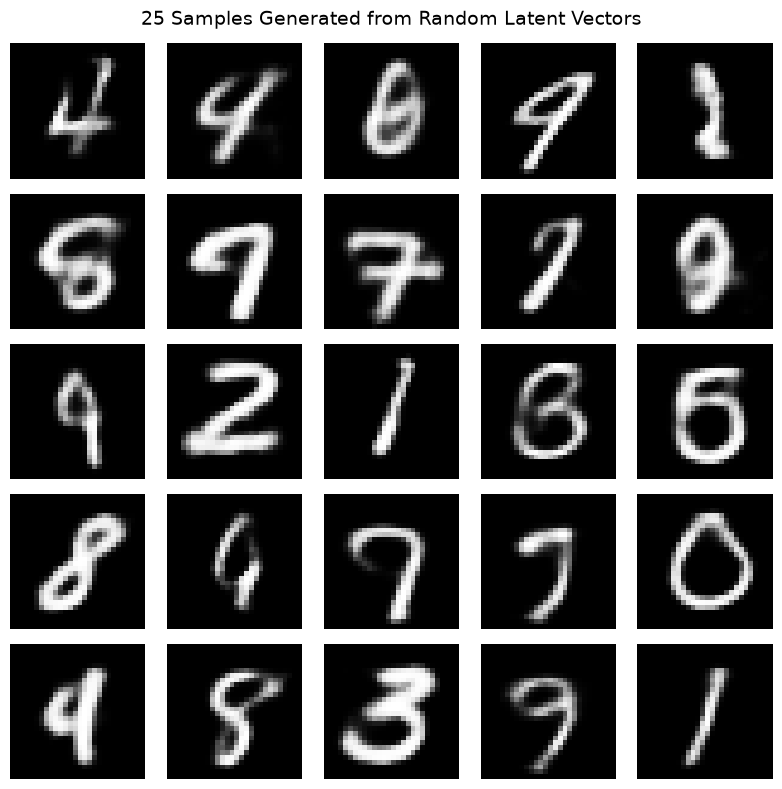

In [38]:
# Displays the twenty-five generated VAE samples.
# Shows the random generations in a five-by-five grid.
fig, axes = plt.subplots(5,5,figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images_25[i].squeeze(),cmap="gray")
    ax.axis("off")

plt.suptitle("25 Samples Generated from Random Latent Vectors",fontsize=14)
plt.tight_layout()
plt.show()

In [39]:
# Computes average test reconstruction loss.
# Evaluates binary reconstruction error over the MNIST test set.
model.eval()
total_reconstruction_loss = 0

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        reconstruction_logits, mu, logvar = model(images)
        flat_images = images.view(images.size(0),-1)
        reconstruction_loss = (F.binary_cross_entropy_with_logits(reconstruction_logits,flat_images,reduction="sum"))
        total_reconstruction_loss += (reconstruction_loss.item())

average_reconstruction_loss = (total_reconstruction_loss/ len(test_loader.dataset))
print("Average Test Reconstruction Loss:", average_reconstruction_loss)

Average Test Reconstruction Loss: 82.87197846679688


# EXTRA EXPERIMENTs

In [40]:
# Sets latent dimensions for the extra VAE experiments.
# Keeps separate models so the original trained VAE is not changed.
latent_experiment_dims = [3,5,10,15]
latent_experiment_epochs = 10
latent_experiment_learning_rate = 1e-3
latent_experiment_samples = 5
latent_experiment_models = {}
latent_experiment_histories = {}
print("Latent dimensions:",latent_experiment_dims)
print("Epochs per model:",latent_experiment_epochs)

Latent dimensions: [3, 5, 10, 15]
Epochs per model: 10


In [41]:
# Defines training for one VAE latent-dimension experiment.
# Returns the trained model and epoch losses for comparison.
def train_latent_experiment(current_latent_dim):
    experiment_model = VAE(input_dim=784,hidden_dim=hidden_dim,latent_dim=current_latent_dim).to(device)
    experiment_optimizer = torch.optim.Adam(experiment_model.parameters(),lr=latent_experiment_learning_rate)
    experiment_history = {"loss": [], "reconstruction": [], "kl": []}

    for epoch in range(1,latent_experiment_epochs + 1):
        experiment_model.train()
        total_loss = 0
        total_reconstruction_loss = 0
        total_kl_loss = 0

        for x, _ in train_loader:
            x = x.to(device,non_blocking=True)
            experiment_optimizer.zero_grad()
            reconstruction_logits, mu, logvar = experiment_model(x)
            loss, reconstruction_loss, kl_loss = vae_loss(reconstruction_logits,x,mu,logvar)
            loss.backward()
            experiment_optimizer.step()
            total_loss += loss.item()
            total_reconstruction_loss += reconstruction_loss.item()
            total_kl_loss += kl_loss.item()

        avg_loss = total_loss / len(train_dataset)
        avg_reconstruction = total_reconstruction_loss / len(train_dataset)
        avg_kl = total_kl_loss / len(train_dataset)
        experiment_history["loss"].append(avg_loss)
        experiment_history["reconstruction"].append(avg_reconstruction)
        experiment_history["kl"].append(avg_kl)
        print(f"d={current_latent_dim} | Epoch [{epoch:02d}/{latent_experiment_epochs}] Loss: {avg_loss:.4f} | Reconstruction: {avg_reconstruction:.4f} | KL: {avg_kl:.4f}")

    return experiment_model, experiment_history

In [42]:
# Trains VAE models with different latent dimensions.
# Stores trained models and losses for later generation.
for current_latent_dim in latent_experiment_dims:
    print("\nTraining VAE with latent dimension:",current_latent_dim)
    experiment_model, experiment_history = train_latent_experiment(current_latent_dim)
    latent_experiment_models[current_latent_dim] = experiment_model
    latent_experiment_histories[current_latent_dim] = experiment_history
print("All latent-dimension experiments completed.")


Training VAE with latent dimension: 3
d=3 | Epoch [01/10] Loss: 166.4947 | Reconstruction: 160.8237 | KL: 5.6709
d=3 | Epoch [02/10] Loss: 143.1520 | Reconstruction: 135.6710 | KL: 7.4811
d=3 | Epoch [03/10] Loss: 138.5367 | Reconstruction: 130.6871 | KL: 7.8496
d=3 | Epoch [04/10] Loss: 135.9523 | Reconstruction: 127.8909 | KL: 8.0614
d=3 | Epoch [05/10] Loss: 134.1466 | Reconstruction: 125.9310 | KL: 8.2156
d=3 | Epoch [06/10] Loss: 132.8997 | Reconstruction: 124.5920 | KL: 8.3077
d=3 | Epoch [07/10] Loss: 131.8249 | Reconstruction: 123.4261 | KL: 8.3989
d=3 | Epoch [08/10] Loss: 131.0177 | Reconstruction: 122.5587 | KL: 8.4590
d=3 | Epoch [09/10] Loss: 130.4380 | Reconstruction: 121.9147 | KL: 8.5232
d=3 | Epoch [10/10] Loss: 129.9258 | Reconstruction: 121.3380 | KL: 8.5878

Training VAE with latent dimension: 5
d=5 | Epoch [01/10] Loss: 156.5701 | Reconstruction: 148.3999 | KL: 8.1702
d=5 | Epoch [02/10] Loss: 129.3313 | Reconstruction: 118.5076 | KL: 10.8237
d=5 | Epoch [03/10] L

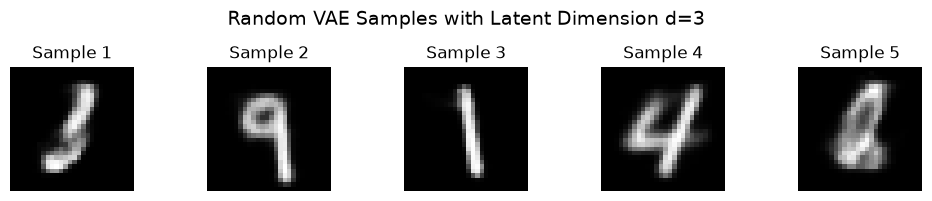

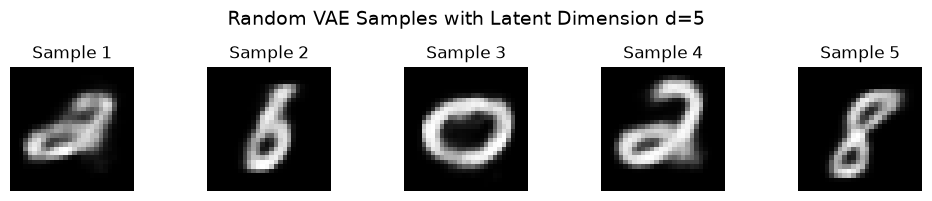

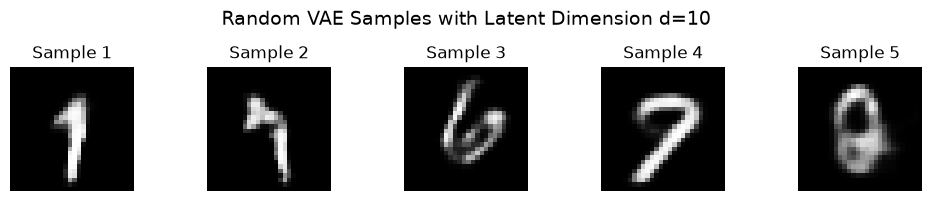

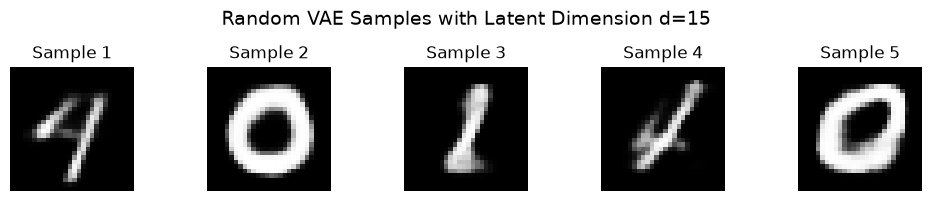

In [43]:
# Generates five random samples from each latent-dimension model.
# Displays each latent dimension in a separate plot.
for current_latent_dim in latent_experiment_dims:
    experiment_model = latent_experiment_models[current_latent_dim]
    experiment_model.eval()

    with torch.no_grad():
        z = torch.randn(latent_experiment_samples,current_latent_dim,device=device)
        generated_logits = experiment_model.decoder(z)
        generated_samples = torch.sigmoid(generated_logits)
        generated_samples = generated_samples.view(-1,1,28,28).cpu()

    fig, axes = plt.subplots(1,latent_experiment_samples,figsize=(10, 2))
    for sample_index in range(latent_experiment_samples):
        axes[sample_index].imshow(generated_samples[sample_index].squeeze(),cmap="gray")
        axes[sample_index].axis("off")
        axes[sample_index].set_title(f"Sample {sample_index + 1}")

    plt.suptitle(f"Random VAE Samples with Latent Dimension d={current_latent_dim}",fontsize=14)
    plt.tight_layout()
    plt.show()